# The GPU batch use case on real data: 39 NOAA tide gauges

One year of hourly water level at 39 [NOAA CO-OPS](https://tidesandcurrents.noaa.gov)
stations is stored as a single `(n_times, n_stations)` array. One `solve_many`
call recovers the tidal constituents at **every** station, from which we map the
M2 amplitude and classify each station's tidal regime — and the result matches the
known oceanography (huge tides in Cook Inlet and the Bay of Fundy; a diurnal Gulf
of Mexico).

*Data: NOAA CO-OPS, public domain.*


In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import utide


## 1. Load the stations


In [2]:
d = np.load("../examples/data/noaa_hourly_2023.npz", allow_pickle=True)
t = d["t_days"].astype(float)
X = d["levels"].astype(float)          # (n_times, n_stations), metres
lats, lons, names = d["lats"], d["lons"], d["names"]
lat0 = float(np.median(lats))
print(X.shape, '-> 39 stations x 8760 hours')


(8760, 39) -> 39 stations x 8760 hours


## 2. One `solve_many` call for every station

`solve_many` uses a single latitude for the (small) nodal correction; the median
of the stations is a fine choice for a one-year fit.


In [3]:
kw = dict(lat=lat0, epoch="2023-01-01", verbose=False)
utide.solve_many(t, X[:, :4], gpu=True, **kw)        # warm up the GPU
t0 = time.perf_counter()
out = utide.solve_many(t, X, gpu=True, **kw)
gpu_t = time.perf_counter() - t0

m2 = list(out.name).index("M2")
ns = 10
sa = np.empty(ns)
t0 = time.perf_counter()
for s in range(ns):
    c = utide.solve(t, X[:, s], method="ols", conf_int="none", **kw)
    sa[s] = c["A"][list(c["name"]).index("M2")]
per = (time.perf_counter() - t0) / ns
print(f"solve_many: {X.shape[1]} stations in {gpu_t:.2f}s")
print(f"per-station solve(): {1000*per:.0f} ms -> naive loop ~= {per*X.shape[1]:.1f}s "
      f"({per*X.shape[1]/gpu_t:.0f}x slower)")
print(f"solve_many vs per-station solve(): max rel diff = "
      f"{np.max(np.abs(sa - out.A[m2, :ns]) / sa):.1e}")


solve_many: 39 stations in 0.11s
per-station solve(): 131 ms -> naive loop ~= 5.1s (45x slower)
solve_many vs per-station solve(): max rel diff = 3.3e-14


## 3. Maps and tidal classification

From the per-station amplitudes we form the tidal *form factor*
F = (K1+O1)/(M2+S2): F < 0.25 is semidiurnal, F > 1.5 is (mixed-)diurnal.

*(Install `cartopy` for the coastline basemap; without it the points are
plotted on plain longitude/latitude axes.)*


largest M2: Anchorage (3.54 m); smallest: Dauphin Island (0.014 m)
diurnal/mixed-diurnal (form>1.5): Panama City, Dauphin Island, Grand Isle, Galveston Bay Entrance, North Jetty, Port Isabel, Adak Island


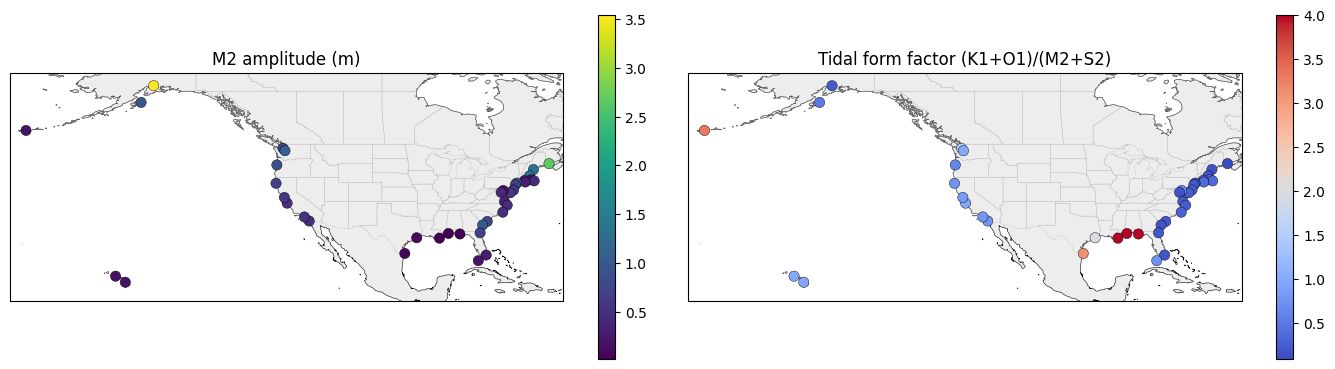

In [4]:
def amp(n): return out.A[list(out.name).index(n)]
M2, S2, K1, O1 = amp("M2"), amp("S2"), amp("K1"), amp("O1")
form = (K1 + O1) / (M2 + S2)
hi, lo = np.argmax(M2), np.argmin(M2)
print(f"largest M2: {names[hi]} ({M2[hi]:.2f} m); smallest: {names[lo]} ({M2[lo]:.3f} m)")
print("diurnal/mixed-diurnal (form>1.5):", ", ".join(np.asarray(names)[form > 1.5]))

try:
    import cartopy.crs as ccrs, cartopy.feature as cfeature
    proj = ccrs.PlateCarree(); spk = {"projection": proj}
except ImportError:
    proj = spk = None
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), subplot_kw=spk)
for a, (title, c, cmap) in zip(ax, [("M2 amplitude (m)", M2, "viridis"),
        ("Tidal form factor (K1+O1)/(M2+S2)", np.clip(form, 0, 4), "coolwarm")]):
    if proj is not None:
        a.add_feature(cfeature.LAND, facecolor="0.93")
        a.add_feature(cfeature.COASTLINE, linewidth=0.4)
        a.add_feature(cfeature.STATES, linewidth=0.2, edgecolor="0.7")
        a.set_extent([-180, -64, 16, 64], crs=proj)
        sc = a.scatter(lons, lats, c=c, s=55, cmap=cmap, edgecolor="k", lw=0.3, transform=proj, zorder=5)
    else:
        sc = a.scatter(lons, lats, c=c, s=55, cmap=cmap, edgecolor="k", lw=0.3); a.set_xlim(-180, -64)
    a.set_title(title); fig.colorbar(sc, ax=a, shrink=0.8)
fig.tight_layout(); plt.show()


That co-amplitude map and tidal classification for all 39 stations came from a
single `solve_many` call. Swap in thousands of model-grid cells or altimetry
points and the same one call scales to them — see `gpu_batch_example.ipynb`.
